# 02 EDA

## 1. Data

In [26]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.rcParams['figure.dpi'] = 120

ROOT = Path.cwd().resolve().parent
PROCESSED_PATH = ROOT / "data" / "processed" / "yrbs_selected_cleaned.csv"
FIG_DIR = ROOT / "outputs" / "figures"
TAB_DIR = ROOT / "outputs" / "tables"

BEHAVIOR_VAR = "EverCigaretteUse"
CONT_VAR = "HowMuchDoYouWeighWithoutShoesInKG"

processed = pd.read_csv(PROCESSED_PATH)
print("Processed data shape:", processed.shape)

Processed data shape: (14041, 3)


In [27]:
#copy
behavior = processed[[BEHAVIOR_VAR, "behavior_binary"]].copy()
behavior_valid = behavior.dropna(subset=["behavior_binary"]).copy()

cont = processed[[CONT_VAR]].copy()
cont_valid = cont.dropna(subset=[CONT_VAR]).copy()

## 2. Behavior Variable EDA

### 2.1 Original code

,raw_code,count,proportion
0,Success (1),7164,0.510
1,Failure (2),6437,0.458
2,Missing or invalid,440,0.031


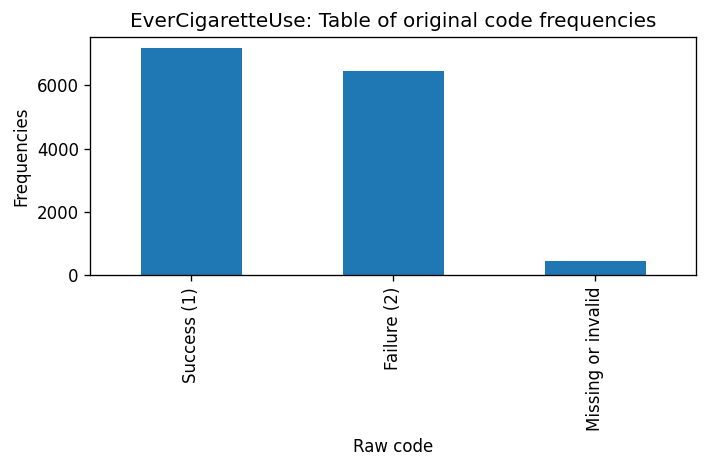

In [28]:
#----------表----------
behavior_raw_freq = (
    behavior[BEHAVIOR_VAR]
    .value_counts(dropna=False)
    .rename_axis("raw_code")
    .reset_index(name="count")
)

behavior_raw_freq["raw_code"] = behavior_raw_freq["raw_code"].astype("object")
behavior_raw_freq["raw_code"] = behavior_raw_freq["raw_code"].where(
    behavior_raw_freq["raw_code"].notna(), "Missing or invalid"
)

# 把原始 code 1, 2 改成更清楚的名稱
behavior_raw_freq["raw_code"] = behavior_raw_freq["raw_code"].replace({
    1: "Success (1)",
    2: "Failure (2)"
})

behavior_raw_freq["proportion"] = (
    behavior_raw_freq["count"] / behavior_raw_freq["count"].sum()
).round(3)

display(behavior_raw_freq)
#----------表----------
#----------圖表----------
raw_plot_counts = (
    behavior[BEHAVIOR_VAR]
    .astype("object")
    .where(behavior[BEHAVIOR_VAR].notna(), "Missing or invalid")
    .value_counts(dropna=False)
    .reindex([1, 2, "Missing or invalid"], fill_value=0)
)
#----------圖表----------
raw_plot_counts.index = ["Success (1)", "Failure (2)", "Missing or invalid"]# 改 x 軸顯示名稱

plt.figure(figsize=(6, 4))
raw_plot_counts.plot(kind="bar")
plt.title("EverCigaretteUse: Table of original code frequencies")
plt.xlabel("Raw code")
plt.ylabel("Frequencies")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_behavior_original_bar_chart.png", bbox_inches="tight")
plt.show()

**Observations:** The original responses are concentrated in codes 1 and 2, with only a smaller number of missing values.

### 2.2 Binary recoding

,category,count,proportion
0,Failure (0),6437,0.473274
1,Success (1),7164,0.526726


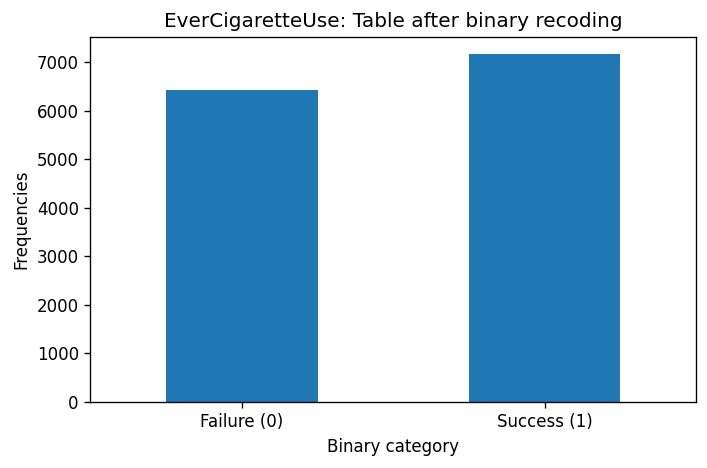

In [29]:
#----------表----------
behavior_binary_summary = pd.DataFrame({
    "category": ["Failure (0)", "Success (1)"],
    "count": [
        int((behavior_valid["behavior_binary"] == 0).sum()),
        int((behavior_valid["behavior_binary"] == 1).sum())
    ]
})
behavior_binary_summary["proportion"] = behavior_binary_summary["count"] / behavior_binary_summary["count"].sum()
behavior_binary_summary.to_csv(TAB_DIR / "02_behavior_binary_summary.csv", index=False)
display(behavior_binary_summary)
#----------圖表----------
binary_plot_counts = behavior_valid["behavior_binary"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
binary_plot_counts.plot(kind="bar")
plt.title("EverCigaretteUse: Table after binary recoding")
plt.xlabel("Binary category")
plt.ylabel("Frequencies")
plt.xticks([0, 1], ["Failure (0)", "Success (1)"], rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_behavior_binary_bar_chart.png", bbox_inches="tight")
plt.show()

**Observations:** After binary recoding, **Success (1)** accounts for **52.7%** of the valid responses, which is slightly higher than **Failure (0)** at **47.3%**. This suggests that the success category is somewhat more common in the sample and may be above the benchmark proportion of **0.50**.

### 2.3 Additional: EverCigaretteUse success proportion by weight quartile

,weight_quartile,success_proportion,sample_size
0,Q1 (lowest),0.4689,3525
1,Q2,0.4965,2852
2,Q3,0.5569,3135
3,Q4 (highest),0.5963,3171


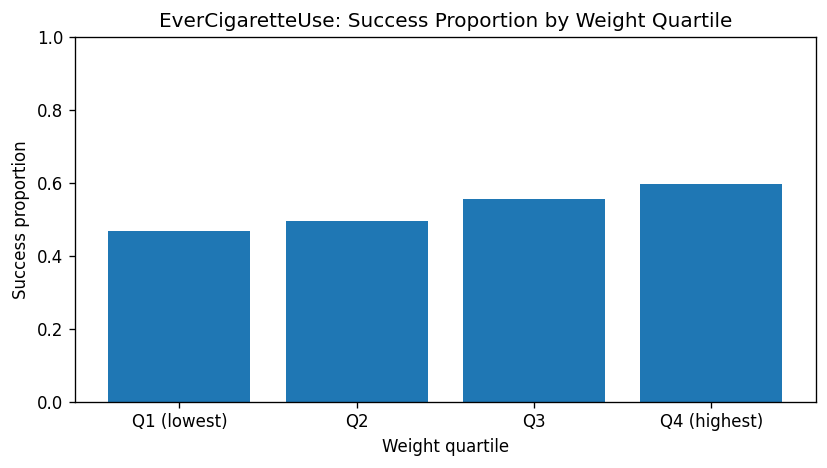

In [30]:
# Additional EDA for behavior variable:
# Success proportion by weight quartile

behavior_weight = processed[["behavior_binary", CONT_VAR]].dropna().copy()

behavior_weight["weight_quartile"] = pd.qcut(
    behavior_weight[CONT_VAR],
    q=4,
    labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"]
)

behavior_by_weight_q = (
    behavior_weight.groupby("weight_quartile", observed=False)["behavior_binary"]
    .agg(success_proportion="mean", sample_size="size")
    .reset_index()
)

behavior_by_weight_q["success_proportion"] = behavior_by_weight_q["success_proportion"].round(4)

behavior_by_weight_q.to_csv(TAB_DIR / "02_behavior_by_weight_quartile.csv", index=False)
display(behavior_by_weight_q)

plt.figure(figsize=(7, 4))
plt.bar(
    behavior_by_weight_q["weight_quartile"].astype(str),
    behavior_by_weight_q["success_proportion"]
)
plt.title("EverCigaretteUse: Success Proportion by Weight Quartile")
plt.xlabel("Weight quartile")
plt.ylabel("Success proportion")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_behavior_by_weight_quartile.png", bbox_inches="tight")
plt.show()

**Observation:** The success proportion tends to increase across the weight quartiles. In this sample, students in the higher weight quartiles show a higher proportion in the success category than those in the lower quartiles. This suggests that the behavior variable may be related to body weight in a descriptive sense, although this EDA result should not be interpreted as a causal relationship.

## 3.Continuous Variable EDA

### 3.1 Statistic and missing or invalid value count

In [31]:
w = cont_valid[CONT_VAR]
summary_stats = pd.DataFrame({
    "statistic": ["valid size", "mean", "median", "sd", "min", "Q1", "Q3", "max", "Missing  or invalid"],
    "value": [
        int(w.shape[0]),
        float(w.mean()),
        float(w.median()),
        float(w.std(ddof=1)),
        float(w.min()),
        float(w.quantile(0.25)),
        float(w.quantile(0.75)),
        float(w.max()),
        int(processed[CONT_VAR].isna().sum())        
    ]
})
summary_stats.to_csv(TAB_DIR / "02_continuous_summary_stats.csv", index=False)
display(summary_stats)

,statistic,value
0,valid size,13062.000000
1,mean,68.550172
2,median,65.320000
3,sd,16.990868
4,min,34.470000
5,Q1,56.700000
6,Q3,77.110000
7,max,180.990000
8,Missing or invalid,979.000000


**Observation**: The sample mean is 68.55 kg and the median is 65.32 kg. Because the mean is above the median, the distribution appears somewhat right-skewed.

### 3.2 Histogram

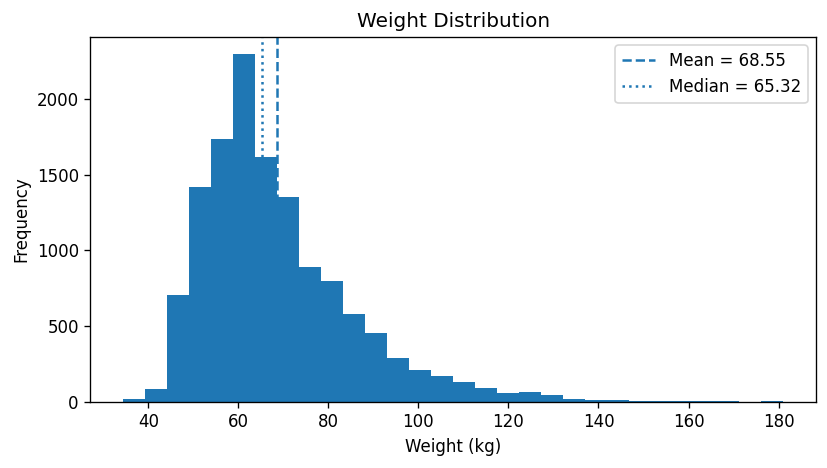

In [32]:
plt.figure(figsize=(7, 4))
plt.hist(w, bins=30)
plt.axvline(w.mean(), linestyle="--", label=f"Mean = {w.mean():.2f}")
plt.axvline(w.median(), linestyle=":", label=f"Median = {w.median():.2f}")
plt.title("Weight Distribution")
plt.xlabel("Weight (kg)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "02_weight_histogram.png", bbox_inches="tight")
plt.show()

**Observation:** The histogram shows a single main cluster with a longer right tail. This supports the idea that unusually high weights pull the mean upward.

### 3.3 Boxplot

,metric,value
0,Q1,56.700
1,Q3,77.110
2,IQR,20.410
3,Lower fence,26.085
4,Upper fence,107.725
5,Outlier count,447.000


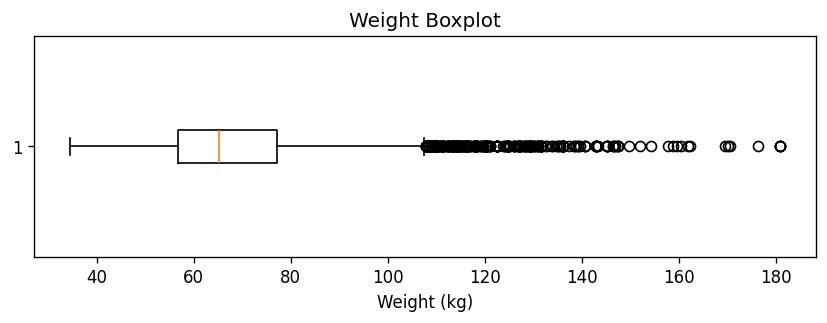

In [33]:
q1 = float(w.quantile(0.25))
q3 = float(w.quantile(0.75))
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outliers = int(((w < lower) | (w > upper)).sum())

outlier_table = pd.DataFrame({
    "metric": ["Q1", "Q3", "IQR", "Lower fence", "Upper fence", "Outlier count"],
    "value": [q1, q3, iqr, lower, upper, outliers]
})
outlier_table.to_csv(TAB_DIR / "02_weight_outlier_check.csv", index=False)
display(outlier_table)

plt.figure(figsize=(7, 2.8))
plt.boxplot(w, vert=False)
plt.title("Weight Boxplot")
plt.xlabel("Weight (kg)")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_weight_boxplot.png", bbox_inches="tight")
plt.show()

**Observation:** The IQR rule flags 447 possible outliers. So the weight variable is not perfectly symmetric, but the sample size is very large, which helps make one-sample t procedures reasonably stable.

### 3.4 Additional: Weight distribution by behavior group

,behavior_group,count,mean,median,sd
0,Failure (0),5977,66.6400,63.50,15.9427
1,Success (1),6706,70.1923,66.68,17.6695


<Figure size 720x480 with 0 Axes>

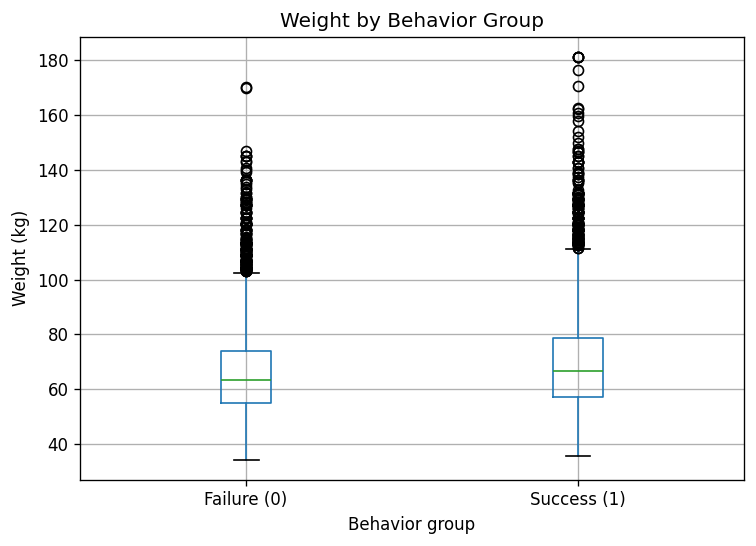

In [34]:
# Additional EDA for continuous variable:
# Weight distribution by behavior group

weight_by_behavior = processed[["behavior_binary", CONT_VAR]].dropna().copy()

weight_by_behavior["behavior_group"] = weight_by_behavior["behavior_binary"].map({
    1: "Success (1)",
    0: "Failure (0)"
})

weight_behavior_summary = (
    weight_by_behavior.groupby("behavior_group")[CONT_VAR]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

weight_behavior_summary = weight_behavior_summary.rename(columns={"std": "sd"})
weight_behavior_summary[["mean", "median", "sd"]] = weight_behavior_summary[["mean", "median", "sd"]].round(4)

weight_behavior_summary.to_csv(TAB_DIR / "02_weight_by_behavior_group.csv", index=False)
display(weight_behavior_summary)

plt.figure(figsize=(6, 4))
weight_by_behavior.boxplot(column=CONT_VAR, by="behavior_group")
plt.title("Weight by Behavior Group")
plt.suptitle("")
plt.xlabel("Behavior group")
plt.ylabel("Weight (kg)")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_weight_by_behavior_group_boxplot.png", bbox_inches="tight")
plt.show()

**Observation:** The weight distribution differs somewhat between the two behavior groups. In this sample, the success group has a higher center than the failure group, suggesting that students in the success category tend to have higher body weight on average. However, this is only a descriptive comparison, so it should not be interpreted as evidence of causation.

## 4 Additional EDA note:

Together, these two figures suggest a **slight positive association** between the behavior variable and body weight in this sample. However, this should be interpreted as a descriptive pattern only, not as evidence of causation.

## Test: Simulate whether T-Test is true or not

=== Raw weight data check ===
n = 13062
mean = 68.5502
median = 65.3200
sd = 16.9909
skewness = 1.4019


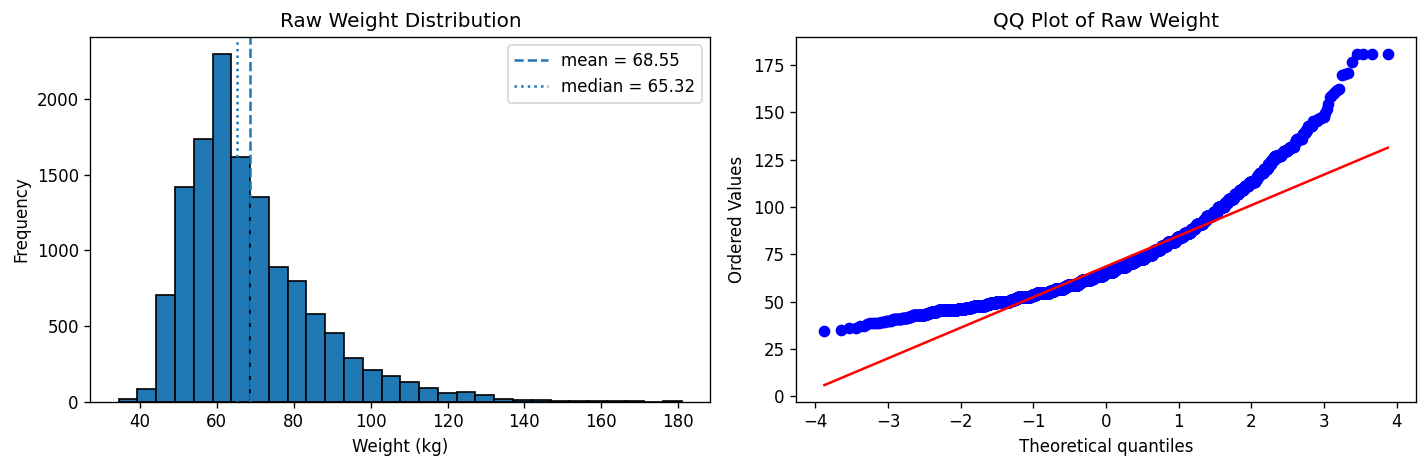


=== Null-centered data check ===
shifted mean = 68.0000 (should be close to 68.0)
shifted skewness = 1.4019

=== Simulation summary ===


,n,mean_of_sample_means,sd_of_sample_means,skewness_of_sample_means,rejection_rate_at_5pct
0,20,67.9153,3.7798,0.2731,0.0700
1,50,68.0295,2.4498,0.2164,0.0627
2,100,68.0057,1.7332,0.1642,0.0587
3,10000,68.0043,0.1693,-0.0524,0.0477


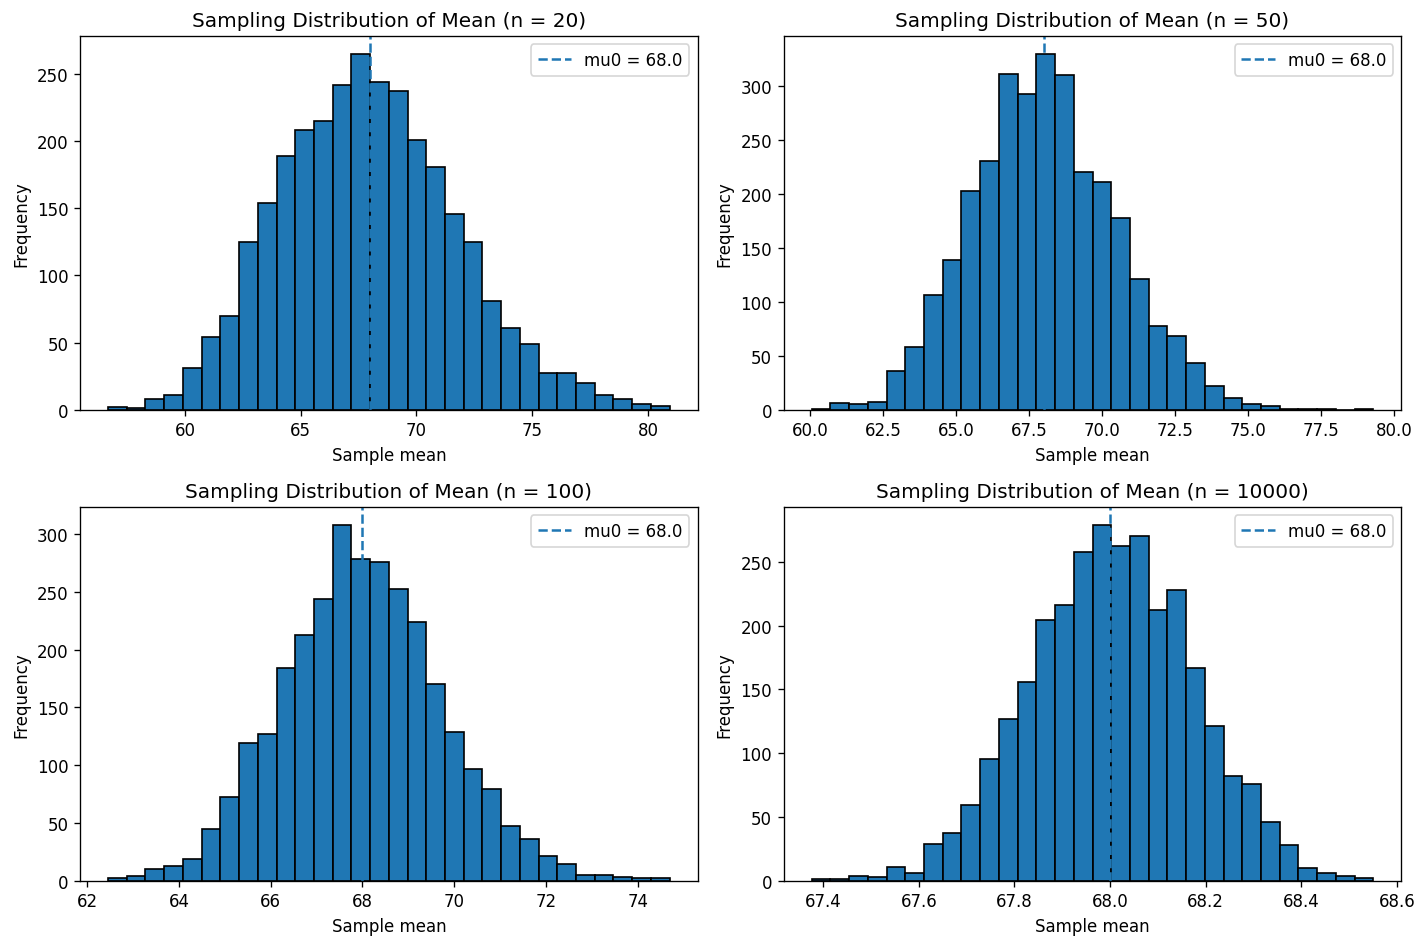


=== How to read the results ===
1. 如果 raw data 的 skewness > 0，代表原始體重分布有右偏傾向。
2. 如果 sample mean distribution 的 skewness 隨 n 變大而變小，代表樣本平均越來越接近常態。
3. 如果 rejection_rate_at_5pct 在大樣本時接近 0.05，代表 one-sample t-test 在這種偏態下仍然算穩健。


In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ===== 0. 讀取你目前已清理好的體重資料 =====
w = processed[CONT_VAR].dropna().to_numpy(dtype=float)
mu0 = 68.0   # 這裡就是 68.0
alpha = 0.05
B = 3000         # 模擬次數，可改成 5000 但會慢一些
sample_sizes = [20, 50, 100, 10000]

print("=== Raw weight data check ===")
print(f"n = {len(w)}")
print(f"mean = {w.mean():.4f}")
print(f"median = {np.median(w):.4f}")
print(f"sd = {w.std(ddof=1):.4f}")
print(f"skewness = {stats.skew(w, bias=False):.4f}")

# ===== 1. 看原始分布：直方圖 + QQ plot =====
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(w, bins=30, edgecolor="black")
axes[0].axvline(w.mean(), linestyle="--", label=f"mean = {w.mean():.2f}")
axes[0].axvline(np.median(w), linestyle=":", label=f"median = {np.median(w):.2f}")
axes[0].set_title("Raw Weight Distribution")
axes[0].set_xlabel("Weight (kg)")
axes[0].set_ylabel("Frequency")
axes[0].legend()

stats.probplot(w, dist="norm", plot=axes[1])
axes[1].set_title("QQ Plot of Raw Weight")

plt.tight_layout()
plt.show()

# ===== 2. 建立「保留原始形狀，但真實平均數等於 mu0」的資料 =====
# 目的：模擬在 H0 成立時，t-test 的拒絕率是否接近 0.05
w_null = w - w.mean() + mu0

print("\n=== Null-centered data check ===")
print(f"shifted mean = {w_null.mean():.4f} (should be close to {mu0:.1f})")
print(f"shifted skewness = {stats.skew(w_null, bias=False):.4f}")

# ===== 3. 模擬不同樣本數下，樣本平均分布 & t-test 拒絕率 =====
rng = np.random.default_rng(13)

results = []
sample_means_dict = {}

for n in sample_sizes:
    means = np.empty(B)
    pvals = np.empty(B)

    for b in range(B):
        sample = rng.choice(w_null, size=n, replace=True)
        means[b] = sample.mean()
        _, pvals[b] = stats.ttest_1samp(sample, popmean=mu0)

    sample_means_dict[n] = means

    results.append({
        "n": n,
        "mean_of_sample_means": means.mean(),
        "sd_of_sample_means": means.std(ddof=1),
        "skewness_of_sample_means": stats.skew(means, bias=False),
        "rejection_rate_at_5pct": (pvals < alpha).mean()
    })

results_df = pd.DataFrame(results)
print("\n=== Simulation summary ===")
display(results_df.round(4))

# ===== 4. 看不同樣本數下，樣本平均分布的形狀 =====
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, n in zip(axes, sample_sizes):
    means = sample_means_dict[n]
    ax.hist(means, bins=30, edgecolor="black")
    ax.axvline(mu0, linestyle="--", label=f"mu0 = {mu0}")
    ax.set_title(f"Sampling Distribution of Mean (n = {n})")
    ax.set_xlabel("Sample mean")
    ax.set_ylabel("Frequency")
    ax.legend()

plt.tight_layout()
plt.show()

# ===== 5. 簡短文字解讀 =====
print("\n=== How to read the results ===")
print("1. 如果 raw data 的 skewness > 0，代表原始體重分布有右偏傾向。")
print("2. 如果 sample mean distribution 的 skewness 隨 n 變大而變小，代表樣本平均越來越接近常態。")
print("3. 如果 rejection_rate_at_5pct 在大樣本時接近 0.05，代表 one-sample t-test 在這種偏態下仍然算穩健。")